In [49]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

SO models work better on normal data which is balanced so we are going to learn about ways how we can normalise data

In [50]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [51]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [52]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [53]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

In [54]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

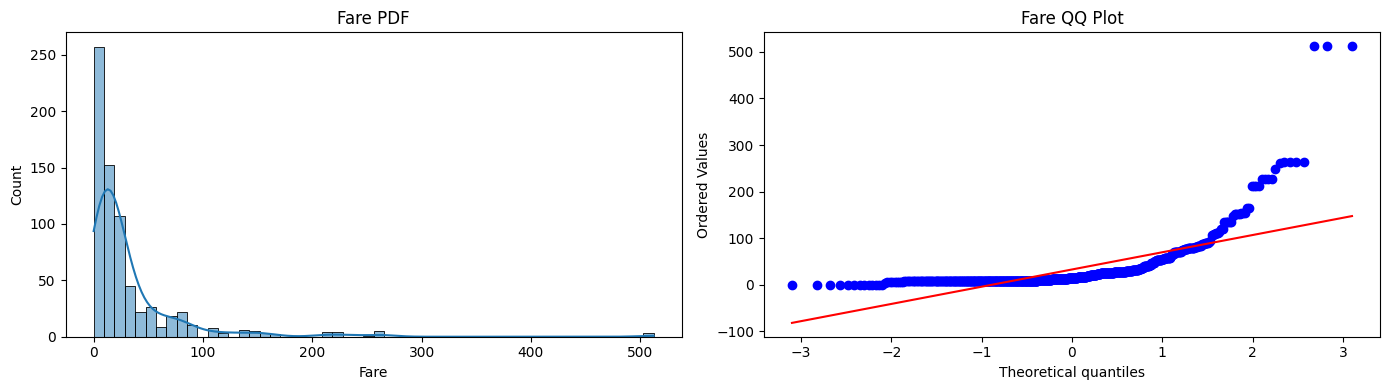

In [56]:
plt.figure(figsize=(14,4))

# First subplot (Left)
plt.subplot(121)
# CHANGED: displot -> histplot (added kde=True to show the curve)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')  # Note: Fixed title text from 'Age' to 'Fare'

# Second subplot (Right)
plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')  # Note: Fixed title text here too

plt.tight_layout()  # Prevents overlapping of labels and plots
plt.show()


**ABOVE FARE GRAPH IS HIGHLY RIGHT SKEWED TO NORMALISE SUCH DATA WE ARE GOING TO USE LOG TRANSFORMATION**

In [57]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [58]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6536312849162011


In [59]:
trf = FunctionTransformer(func = np.log1p)
#np.log1p does is it adds 1 to data so no data is 0 and then does the log of them

In [60]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)


In [61]:
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.7374301675977654
Accuracy DT 0.5921787709497207


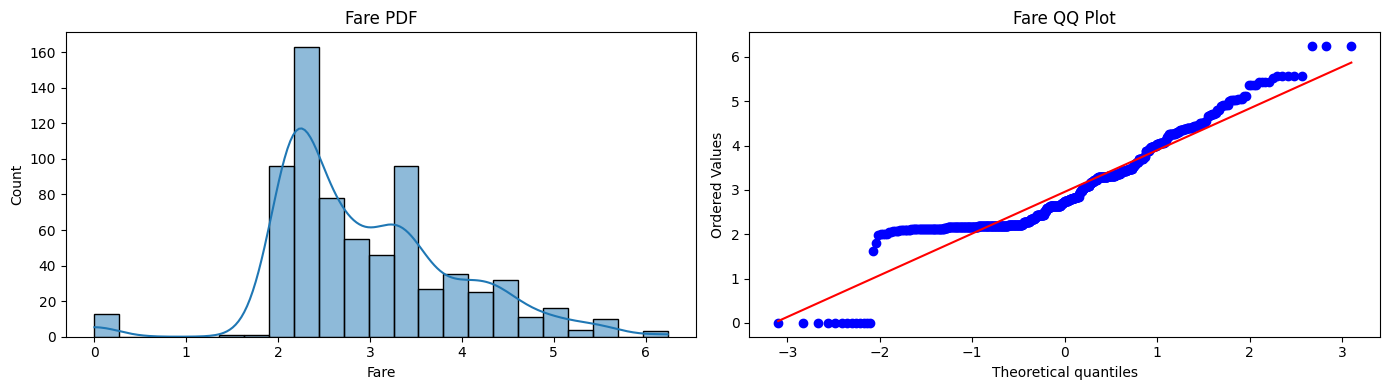

In [62]:
plt.figure(figsize=(14, 4))

# First subplot (Left)
plt.subplot(121)
# CHANGED: displot -> histplot (added kde=True to match a PDF style if desired)
sns.histplot(X_train_transformed['Fare'], kde=True) 
plt.title('Fare PDF') # Note: Fixed your title from 'Age PDF' to 'Fare PDF'

# Second subplot (Right)
plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot') # Note: Fixed title here too

plt.tight_layout() # Keeps plots from overlapping
plt.show()


In [63]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6565917602996255


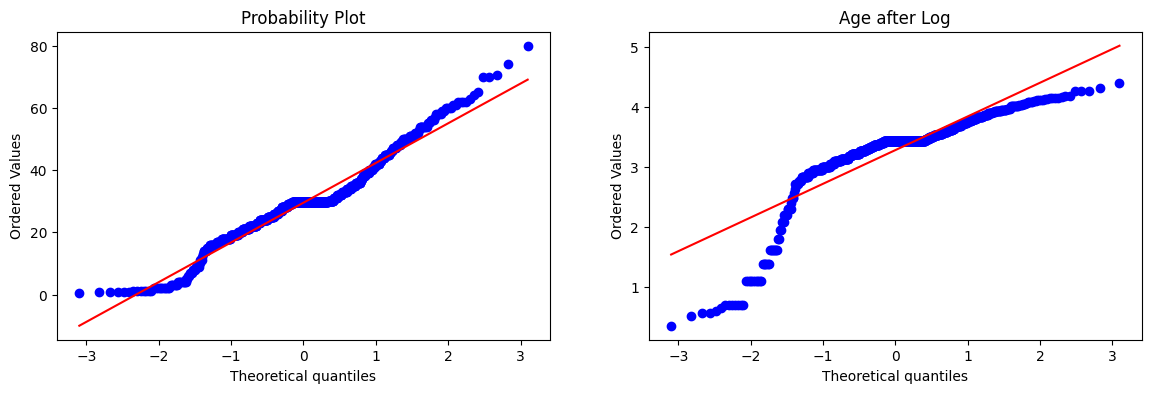

In [64]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist="norm",plot=plt)
plt.title('Age after Log')
plt.show()

In [65]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')
X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.fit_transform(X_test)

In [66]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)


In [67]:
print("Accuracy LF",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))


Accuracy LF 0.6703910614525139
Accuracy DT 0.6480446927374302


In [68]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6599625468164795


In [70]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    trf=ColumnTransformer ([('log', FunctionTransformer (transform),         ['Fare'])], remainder = 'passthrough')
    X_trans=trf.fit_transform(X)
    clf=LogisticRegression()
    print("Accuracy", np.mean (cross_val_score (clf,X_trans, y, scoring='accuracy', cv=10)))
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(X[ 'Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')
    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')
    plt.show()

Accuracy 0.6589013732833957


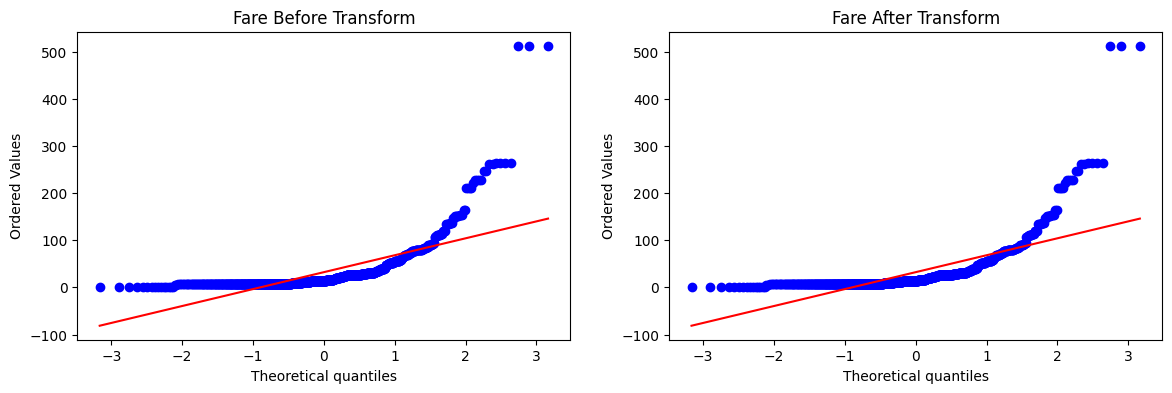

In [85]:
apply_transform(lambda x:x)